This .ipynb notebook serves as a simple inference demo for BIM-JEPA-finetuned-ifcnetcore

HF link: https://huggingface.co/llama2thedog/BIM-JEPA-hf

We inference it on some IFCNetCore test samples

In [1]:
# takes about 4 minutes to install the packages
%%capture
!pip uninstall -y torch torchvision torchaudio xformers
!pip install --index-url https://download.pytorch.org/whl/cu121 torch==2.4.1 torchvision==0.19.1
!pip install -q pytorch-lightning==2.5.3 torchmetrics
# installation for pytorch3d below will take about 40 minutes, but i have already downloaded it onto HF
# so simply just download the whl from the HF!
# !pip install "git+https://github.com/facebookresearch/pytorch3d.git"
!pip install https://huggingface.co/llama2thedog/BIM-JEPA-hf/resolve/main/pytorch3d-0.7.9-cp312-cp312-linux_x86_64.whl

In [2]:
import os
import sys
import zipfile
from huggingface_hub import snapshot_download

HF_REPO_ID = "llama2thedog/BIM-JEPA-hf"

print("Downloading BIM-JEPA Code, Checkpoints, and Dataset from HuggingFace...")

# 1. Download everything instantly from your HF Dataset repo into /content/
snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir="/content/",
)

# 2. Find the zip file you uploaded and automatically unzip it
ZIP_NAME = "processed_IFCNetCore_pointclouds_4096_test.zip"
ZIP_PATH = f"/content/{ZIP_NAME}"

if os.path.exists(ZIP_PATH):
    print(f"Unzipping {ZIP_NAME}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        # Automatically extract into /content/
        zip_ref.extractall("/content/")
    print("Unzip complete!")

# 3. Configure the exact paths now that everything is downloaded and unzipped
REPO_ROOT = "/content"
CKPT_PATH = "/content/checkpoints/epoch=349-step=60550.ckpt"
DATA_DIR  = "/content/processed_IFCNetCore_pointclouds_4096_test"

# Tell python to look for the codebase in REPO_ROOT
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("\n✅ All Data Paths configured!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Unzipping processed_IFCNetCore_pointclouds_4096_test.zip...
Unzip complete!

✅ All Data Paths configured!


In [3]:
# @title
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass
print("Device:", device)

from bimjepa.models.classification import BimJepaClassification
from bimjepa.utils.checkpoint import extract_model_checkpoint
from bimjepa.datasets.ifcnet_datamodule import IFCNetCoreDataModule

# 1) Instantiate the module (no setup call!)
model = BimJepaClassification()

# 2) Read the raw checkpoint state_dict
sd = extract_model_checkpoint(CKPT_PATH)

# 3) Infer num_classes and head style from checkpoint
def infer_head_info(state):
    if "cls_head.weight" in state and state["cls_head.weight"].ndim == 2:
        return state["cls_head.weight"].shape[0], "linear"
    last_idx, last_shape = -1, None
    for k, v in state.items():
        m = re.match(r"^cls_head\.(\d+)\.weight$", k)
        if m:
            i = int(m.group(1))
            if i > last_idx:
                last_idx, last_shape = i, v.shape
    if last_shape is not None:
        return last_shape[0], "mlp"
    return 20, "linear"

NUM_CLASSES, HEAD_TYPE = infer_head_info(sd)
print(f"Inferred head: {HEAD_TYPE}, num_classes={NUM_CLASSES}")

# 4) Build a head that matches the checkpoint
if HEAD_TYPE == "mlp":
    model.cls_head = nn.Sequential(
        nn.Linear(model.first_cls_head_dim, model.hparams.cls_head_dim * 2, bias=False),
        nn.BatchNorm1d(model.hparams.cls_head_dim * 2),
        nn.ReLU(),
        nn.Dropout(model.hparams.cls_head_dropout),
        nn.Linear(model.hparams.cls_head_dim * 2, model.hparams.cls_head_dim, bias=False),
        nn.BatchNorm1d(model.hparams.cls_head_dim),
        nn.ReLU(),
        nn.Dropout(model.hparams.cls_head_dropout),
        nn.Linear(model.hparams.cls_head_dim, NUM_CLASSES),
    )
else:
    model.cls_head = nn.Linear(model.first_cls_head_dim, NUM_CLASSES)

# 5) Load ALL weights
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys (first 10):", [k for k in missing if k.startswith("cls_head.")][:10])
print("Unexpected (first 10):", unexpected[:10])

# 6) Move to device AFTER the head exists
model.to(device).eval()
print("cls_head device:", next(model.cls_head.parameters()).device)

# 7) Prepare the datamodule mappings
dm = IFCNetCoreDataModule(
    data_dir=DATA_DIR,
    batch_size=1,
    num_workers=0,
    val_split_ratio=0.0,
    seed=42,
)

for stage in ["fit","validate","test","predict"]:
    try: dm.setup(stage)
    except Exception: pass

class_to_idx = getattr(dm, "class_to_idx", {})
idx_to_class = {v:k for k,v in class_to_idx.items()}
print("Num classes detected on disk:", len(idx_to_class))

Device: cuda


/content/bimjepa/utils/checkpoint.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location="cuda:0")


Inferred head: mlp, num_classes=20
Missing keys (first 10): []
Unexpected (first 10): []
cls_head device: cuda:0
IFCNetCoreDataModule setup complete:
 - Found 20 classes.
 - Train samples: 0
 - Validation samples: 0
 - Test samples: 2379
IFCNetCoreDataModule setup complete:
 - Found 20 classes.
 - Train samples: 0
 - Validation samples: 0
 - Test samples: 2379
IFCNetCoreDataModule setup complete:
 - Found 20 classes.
 - Train samples: 0
 - Validation samples: 0
 - Test samples: 2379
IFCNetCoreDataModule setup complete:
 - Found 20 classes.
 - Train samples: 0
 - Validation samples: 0
 - Test samples: 2379
Num classes detected on disk: 20


Visualization code

In [4]:
# @title
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def predict_file(path: str):
    if not os.path.isfile(path):
        raise FileNotFoundError(path)
    arr = np.load(path)

    if arr.ndim != 2 or arr.shape[1] < 3:
        raise ValueError(f"Expected (N, >=3) array, got {arr.shape}")
    pts_xyz = arr[:, :3].astype(np.float32)

    pts = torch.from_numpy(pts_xyz).unsqueeze(0).to(device)

    with torch.no_grad():
        if hasattr(model, "val_transformations"):
            pts = model.val_transformations(pts)
        logits = model(pts)
        probs = F.softmax(logits, dim=-1)[0].cpu()

        pred_idx = int(torch.argmax(probs).item())
        pred_name = idx_to_class.get(pred_idx, f"class_{pred_idx}")
        pred_prob = float(probs[pred_idx].item())
    return pred_idx, pred_name, pred_prob

def _actual_from_path(path: str, data_root: str) -> str:
    rel = os.path.relpath(path, data_root)
    return rel.split(os.sep)[0]

def _equal_aspect_3d(ax, X, Y, Z):
    xmin, xmax = np.min(X), np.max(X)
    ymin, ymax = np.min(Y), np.max(Y)
    zmin, zmax = np.min(Z), np.max(Z)
    max_range = max(xmax-xmin, ymax-ymin, zmax-zmin)
    xmid = 0.5*(xmax+xmin)
    ymid = 0.5*(ymax+ymin)
    zmid = 0.5*(zmax+zmin)
    half = 0.5*max_range if max_range > 0 else 1.0
    ax.set_xlim(xmid-half, xmid+half)
    ax.set_ylim(ymid-half, ymid+half)
    ax.set_zlim(zmid-half, zmid+half)

def visualize_pointcloud_with_labels(path: str, data_root: str):
    arr = np.load(path)
    if arr.ndim != 2 or arr.shape[1] < 3:
        raise ValueError(f"Expected (N, >=3) array, got {arr.shape}")
    pts_np = arr[:, :3].astype(np.float32)

    pred_idx, pred_name, pred_prob = predict_file(path)
    actual_name = _actual_from_path(path, data_root)

    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection='3d')

    PLOT_MAX = 4096
    if len(pts_np) > PLOT_MAX:
        idx = np.random.choice(len(pts_np), PLOT_MAX, replace=False)
        pc_show = pts_np[idx]
    else:
        pc_show = pts_np
    ax.scatter(pc_show[:,0], pc_show[:,1], pc_show[:,2], s=1)

    _equal_aspect_3d(ax, pc_show[:,0], pc_show[:,1], pc_show[:,2])
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(os.path.basename(path))

    correct = (pred_name == actual_name)
    info = [
        f"Predicted: {pred_name}",
        f"Confidence: {pred_prob:.3f}",
        f"Actual: {actual_name}",
        f"Match: {'YES' if correct else 'NO'}"
    ]
    plt.tight_layout(rect=[0, 0, 0.78, 1])
    fig.text(0.82, 0.55, "\n".join(info), va='top', ha='left')
    plt.show()

The cell below shows the top 5 files in the 'processed_IFCNetCore_pointclouds_4096_test' folder.

You can manually list files under SAMPLE_FILES

Auto-selected 5 files.
 - /content/processed_IFCNetCore_pointclouds_4096_test/IfcAirTerminal/test/0040c7bf0e474141bb19bdf8ed59e080.npy
 - /content/processed_IFCNetCore_pointclouds_4096_test/IfcAirTerminal/test/04327ff13a5547a3b2ab3fa7377d5a26.npy
 - /content/processed_IFCNetCore_pointclouds_4096_test/IfcAirTerminal/test/074813d22a894bd299966b7fb2163749.npy
 - /content/processed_IFCNetCore_pointclouds_4096_test/IfcAirTerminal/test/09436112504444c08a798db5b213f1ed.npy
 - /content/processed_IFCNetCore_pointclouds_4096_test/IfcAirTerminal/test/096f0d41983e4ac5b3b3f54485a9dc8c.npy

[1] 0040c7bf0e474141bb19bdf8ed59e080.npy


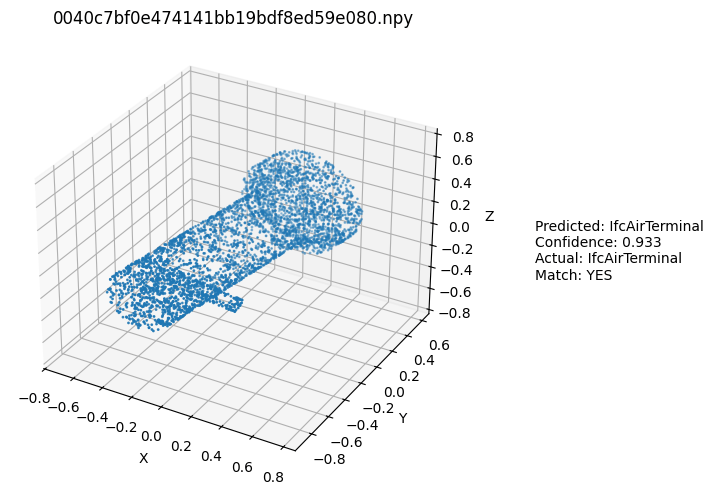


[2] 04327ff13a5547a3b2ab3fa7377d5a26.npy


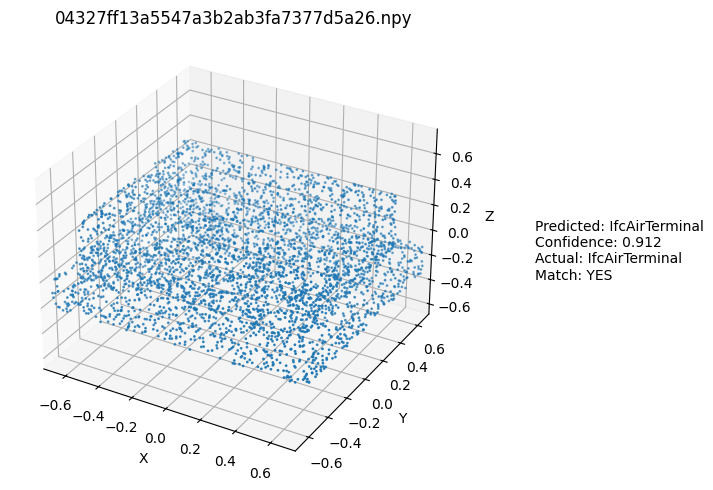


[3] 074813d22a894bd299966b7fb2163749.npy


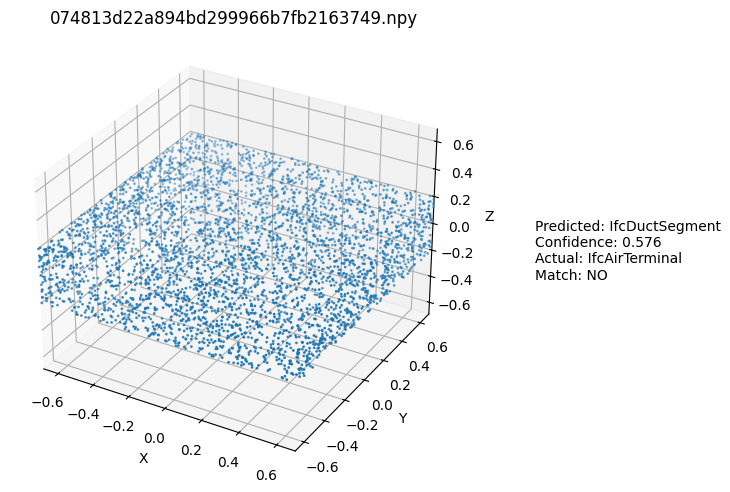


[4] 09436112504444c08a798db5b213f1ed.npy


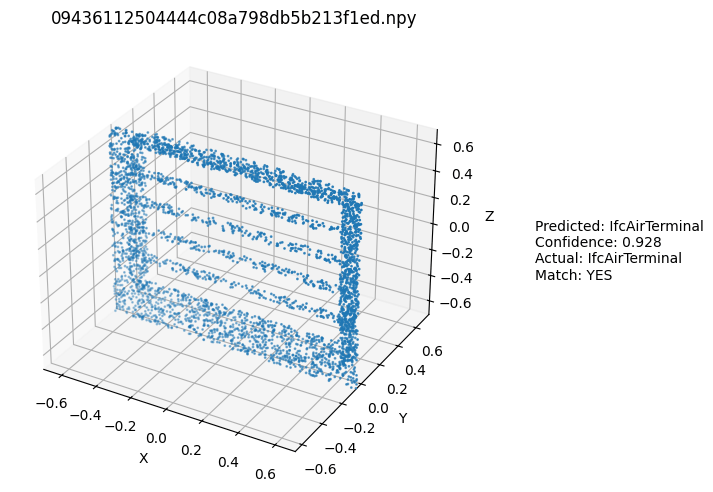


[5] 096f0d41983e4ac5b3b3f54485a9dc8c.npy


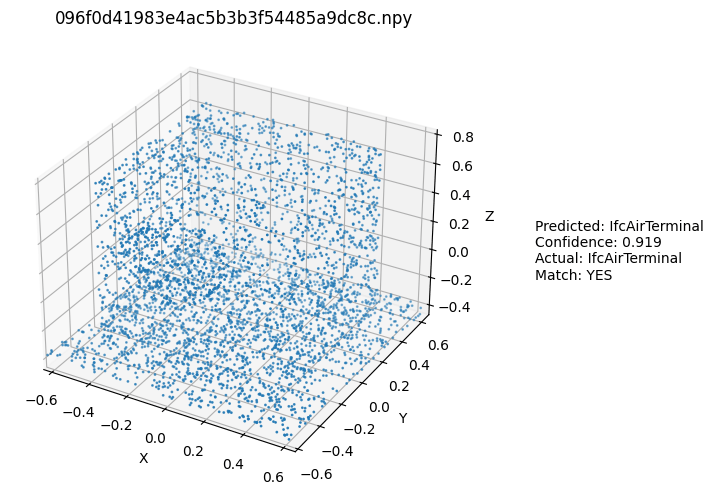

In [5]:
# @title
# --- Run the visualization for your 5 demo files ---
import glob

SAMPLE_FILES = []  # or list your 5 paths explicitly

if not SAMPLE_FILES:
    found = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.npy"), recursive=True))
    SAMPLE_FILES = found[:5] # UPDATE THIS TO CHANGE THE VIEWING OF CLASSES <<
    print(f"Auto-selected {len(SAMPLE_FILES)} files.")
    for p in SAMPLE_FILES: print(" -", p)

for i, p in enumerate(SAMPLE_FILES, 1):
    print(f"\n[{i}] {os.path.basename(p)}")
    try:
        visualize_pointcloud_with_labels(p, DATA_DIR)
    except Exception as e:
        print("ERROR:", e)


This cell below randomly visualize 5 files in 'processed_IFCNetCore_pointclouds_4096_test'

Selected 5 files:
 - /content/processed_IFCNetCore_pointclouds_4096_test/IfcSanitaryTerminal/test/63df0337c37c473ba39d751d8a0c75c9.npy
 - /content/processed_IFCNetCore_pointclouds_4096_test/IfcValve/test/67d646528ed948c393e6790b36201141.npy
 - /content/processed_IFCNetCore_pointclouds_4096_test/IfcSlab/test/5baa9e9e4de14f01a98a7c5039f953ba.npy
 - /content/processed_IFCNetCore_pointclouds_4096_test/IfcDuctFitting/test/d2eea27fe72a49bab468dc365836671a.npy
 - /content/processed_IFCNetCore_pointclouds_4096_test/IfcPipeSegment/test/68ae602696054ff78a08dd11d8e6db51.npy

[1] 63df0337c37c473ba39d751d8a0c75c9.npy


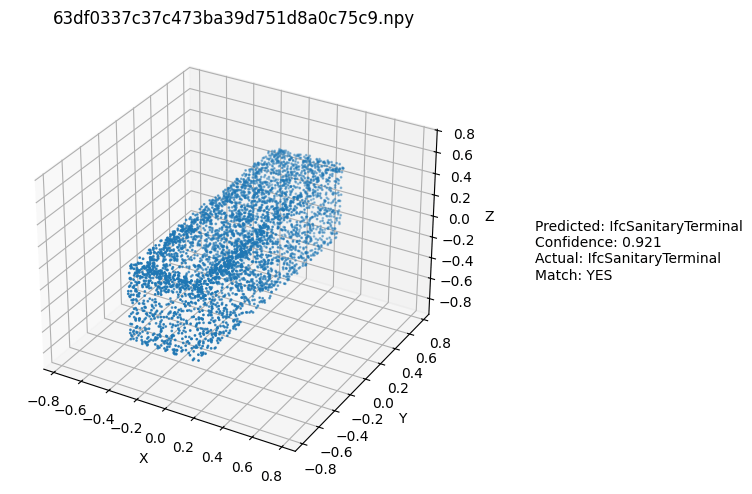


[2] 67d646528ed948c393e6790b36201141.npy


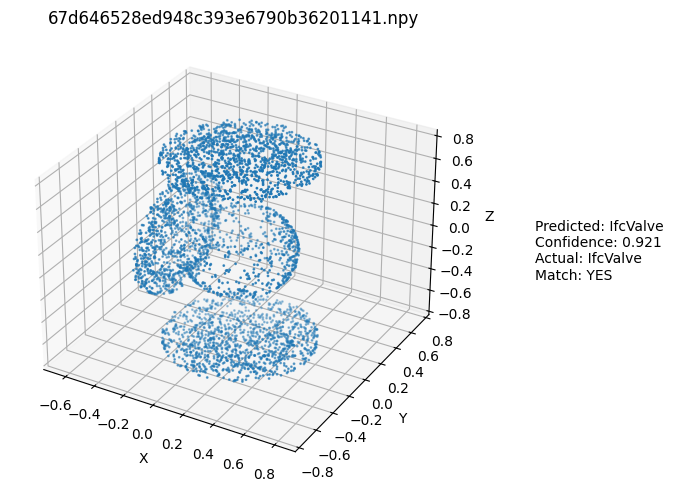


[3] 5baa9e9e4de14f01a98a7c5039f953ba.npy


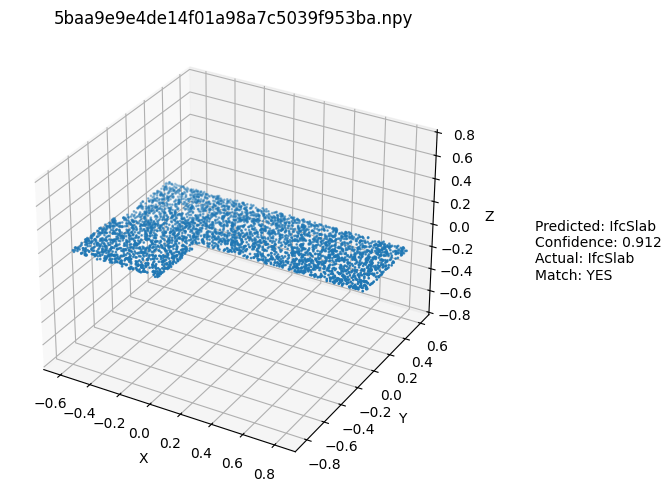


[4] d2eea27fe72a49bab468dc365836671a.npy


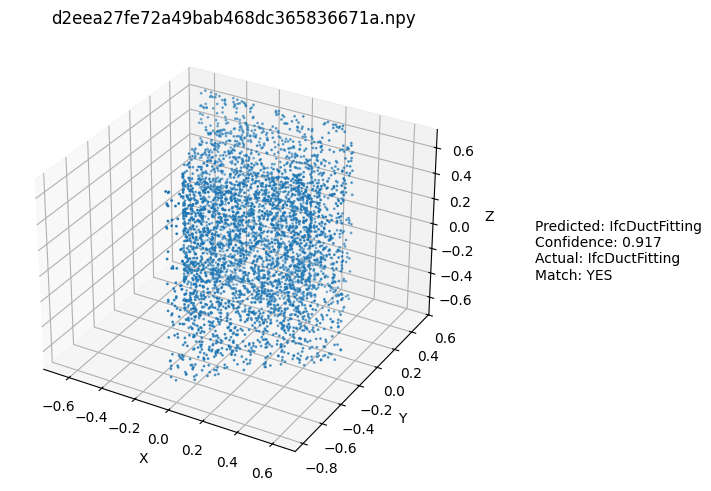


[5] 68ae602696054ff78a08dd11d8e6db51.npy


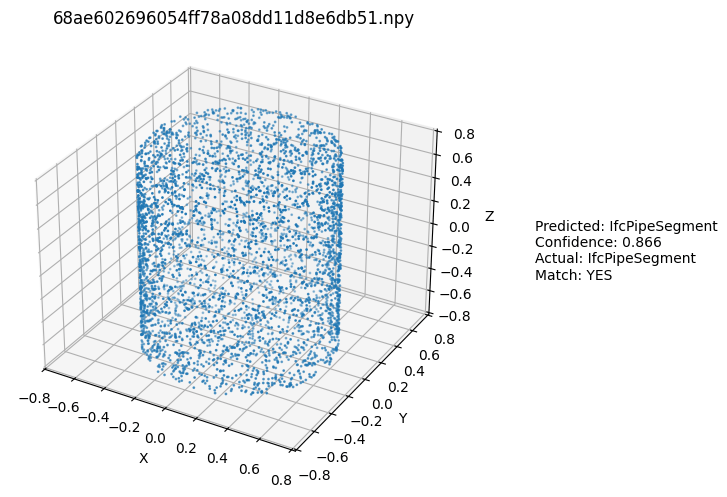

In [8]:
# @title
# --- Run the visualization for your 5 demo files (with random toggle) ---
import os, glob, random

N_SAMPLES = 5 # CHANGE THIS TO VIEW MORE OR LESS
RANDOM_PICK = True            # True -> random pick (not folder order)
STRATIFIED_PER_CLASS = False  # True -> pick at most one file per class first
SEED = None                   # set None for non-reproducible randomness

if SEED is not None:
    random.seed(SEED)

found = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.npy"), recursive=True))
if not found:
    raise RuntimeError("No .npy files found under DATA_DIR.")

def _class_of(path: str, root: str) -> str:
    rel = os.path.relpath(path, root)
    return rel.split(os.sep)[0]

SAMPLE_FILES = []

if STRATIFIED_PER_CLASS:
    # Group by class, take at most 1 per class (randomly), then fill remaining randomly
    from collections import defaultdict
    by_class = defaultdict(list)
    for p in found:
        by_class[_class_of(p, DATA_DIR)].append(p)

    classes = list(by_class.keys())
    random.shuffle(classes)

    # 1-per-class first
    for cls in classes:
        if len(SAMPLE_FILES) >= N_SAMPLES:
            break
        SAMPLE_FILES.append(random.choice(by_class[cls]))

    # If we still need more, fill from remaining pool
    if len(SAMPLE_FILES) < N_SAMPLES:
        remaining = [p for p in found if p not in set(SAMPLE_FILES)]
        if RANDOM_PICK:
            extra = random.sample(remaining, k=min(N_SAMPLES - len(SAMPLE_FILES), len(remaining)))
        else:
            extra = remaining[:max(0, N_SAMPLES - len(SAMPLE_FILES))]
        SAMPLE_FILES.extend(extra)

else:
    if RANDOM_PICK:
        SAMPLE_FILES = random.sample(found, k=min(N_SAMPLES, len(found)))
    else:
        SAMPLE_FILES = found[:min(N_SAMPLES, len(found))]

print(f"Selected {len(SAMPLE_FILES)} files:")
for p in SAMPLE_FILES:
    print(" -", p)

# --- visualize ---
for i, p in enumerate(SAMPLE_FILES, 1):
    print(f"\n[{i}] {os.path.basename(p)}")
    try:
        visualize_pointcloud_with_labels(p, DATA_DIR)
    except Exception as e:
        print("ERROR:", e)
